The standalone script for figure plotting for case "C0016R00", avoiding the repeated time consumption on calculating the temperature distribution



In [35]:
# read the power generation profile per time step

import csv
import os
import sys
import numpy as np
import pandas as pd

# data file name
PROJECT_ROOT = os.path.abspath("../..")
sys.path.append(PROJECT_ROOT)

import lib.BTMS_model as BTMS_model
import CoolProp.CoolProp as CP


file_name = os.path.join(PROJECT_ROOT, 'data', 'MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx')

# read the data from the csv file
time_steps = []
power_generation = []

df = pd.read_excel(file_name, sheet_name='Sheet1')

# extract the power generation data 
power_generation_data = df['Qbat(W)'].values[1:]


In [36]:
import numpy as np
from io import StringIO
import os

# Old results sent by LIU
# types = (
#     ('avg', 'MD05E070210A2  data_aircooling BTMS_temperature_avg.out'),
#     ('max', 'MD05E070211A2  data_aircooling BTMS_temperature_max.out'),
#     ('min', 'MD05E070212A2  data_aircooling BTMS_temperature_min.out')
# )
# col_map = {
#     'time_step': 0,
#     'flow_time': 1,
#     'report_def_0': 2
# }

# # A newer result sent by Liu, who added the periodic boundary condition and the set the 2nd order upwind scheme for the Fluent simulation, which is more accurate and closer to the experimental result.

# folder_name = 'HP02E030113A1  result_T_min, max, avg_air cooling_CFD_Liu_20260618'

# types = (
#     ('avg', os.path.join(folder_name, 'avg.out')),
#     ('max', os.path.join(folder_name, 'max.out')),
#     ('min', os.path.join(folder_name, 'min.out'))
# )

# col_map = {
#     'time_step': 0,
#     'flow_time': 2,
#     'report_def_0': 1
# }

# A new set of data sent by Liu, where the max and min values are calculated per battery cell, not the global ones. 

folder_name = 'HP02E030113A2  result_T_peak_avg per bat cell_air cooling_CFD_Liu_20260625'

types = (
    ('avg', os.path.join(folder_name, 'avg.out')),
    ('max', os.path.join(folder_name, 'max.out')),
    ('min', os.path.join(folder_name, 'min.out'))
)

col_map = {
    'time_step': 0,
    'flow_time': 1,
    'report_def_0': 2
}

temperature_cfd_data = {}  # dictionary to store CFD temperature data for each type

for t, file_name in types:
    file_name_cfd = os.path.join(PROJECT_ROOT, 'data', file_name)

    # Parse the Fluent report file: skip header lines starting with '"' and '(', read space-separated columns
    with open(file_name_cfd, 'r') as f:
        lines = [line.strip() for line in f if line.strip() and not line.strip().startswith('"') and not line.strip().startswith('(')]

    data_cfd = np.loadtxt(StringIO('\n'.join(lines)))
    time_step_cfd = data_cfd[:, col_map['time_step']].astype(int)
    flow_time_cfd = data_cfd[:, col_map['flow_time']]
    report_def_0_cfd = data_cfd[:, col_map['report_def_0']]  # avg battery temperature from CFD [K]
    
    temperature_cfd_data[t] = (flow_time_cfd, report_def_0_cfd)
    
print("CFD temperature data loaded for types:", list(temperature_cfd_data.keys()))
print("Example data for 'avg':", max(temperature_cfd_data['avg'][1]))  # print first 5 entries for 'avg' type to verify



CFD temperature data loaded for types: ['avg', 'max', 'min']
Example data for 'avg': 320.1392930834928


In [37]:
def compare_curves_by_stage(
    stage_boundaries,
    stage_names,
    curve_a,
    curve_b,
    time_axis,
    curve_a_name='Curve A',
    curve_b_name='Curve B'
):
    """Compare two curves by stage using max divergence and MSE."""
    curve_a = np.asarray(curve_a)
    curve_b = np.asarray(curve_b)
    time_axis = np.asarray(time_axis)

    if not (len(curve_a) == len(curve_b) == len(time_axis)):
        raise ValueError('curve_a, curve_b, and time_axis must have the same length.')

    diff = curve_a - curve_b
    
    t_stage = [0] + list(stage_boundaries)
    rows = []

    print(f"{curve_a_name}(a) vs. {curve_b_name}(b) comparison for each stage:")
    print(f"{'Stage':<40} {'Time (s)':<20} {'Max_a':<20} {'Max_b':<20} {'Max Divergence (degC)':<30} {'MSE':<20}")

    for i in range(len(t_stage) - 1):
        t_start = t_stage[i]
        t_end = t_stage[i + 1]

        idx_start = np.searchsorted(time_axis, t_start)
        idx_end = np.searchsorted(time_axis, t_end)

        diff_stage = diff[idx_start:idx_end]
        if diff_stage.size == 0:
            continue

        max_divergence = np.max(np.abs(diff_stage))
        mse_stage = np.mean(diff_stage**2)
        max_a = np.max(curve_a[idx_start:idx_end])
        max_b = np.max(curve_b[idx_start:idx_end])
        
        stage_name = stage_names[i] if i < len(stage_names) else f'Stage {i + 1}'
        rows.append({
            'stage': stage_name,
            't_start': t_start,
            't_end': t_end,
            'max_a': max_a,
            'max_b': max_b,
            'max_divergence': max_divergence,
            'mse': mse_stage,
        })

        print(f"{stage_name:<40} {t_start}-{t_end:<20} {max_a:<20.2f} {max_b:<20.2f} {max_divergence:<30.2f} {mse_stage:<20.3g}")

    
    max_divergence_global = np.max(np.abs(diff))
    mse_global = np.mean(diff**2)

    rows.append({
        'stage': 'Global',
        't_start': t_stage[0],
        't_end': t_stage[-1],
        'max_a': np.max(curve_a),
        'max_b': np.max(curve_b),
        'max_divergence': max_divergence_global,
        'mse': mse_global,
    })

    print(f"{'Global':<40} {t_stage[0]}-{t_stage[-1]:<20} {np.max(curve_a):<20.2f} {np.max(curve_b):<20.2f} {max_divergence_global:<30.2f} {mse_global:<20.3g}")

    return (pd.DataFrame(rows),diff)

In [38]:
from scipy.interpolate import interp1d

# load the calculation result from previously saved excel file
import pandas as pd
import numpy as np
import os

# plot the experimental temperature data from Park's paper for comparison
t_park = [6, 36, 180, 1560, 1632, 1719, 1824, 1917]
T_park = [298.7, 300.1, 302.25, 299.84, 300.5, 300.84, 310.45, 320.31]  # Park's experimental temperature data in Kelvin
stages = [
    'A: Take-off',
    'B: Ascent Transition',
    'C: Acceleration',
    'D: Cruise',
    'E: Deceleration',
    'F: Descent Transition',
    'G: Hovering',
    'H: Landing'
]  # corresponding stages for Park's experimental data

CASE_ID = 'C0016'
CASE_NAME = 'C0016R00_PARK25_AC_THERM_1D_VAL'

file_name = os.path.join(PROJECT_ROOT, 'data', CASE_ID, f'{CASE_NAME}.xlsx')

seg_num = 20  # number of segments in the battery pack

data = pd.read_excel(file_name)  # read the excel file into a pandas DataFrame

# use the time steps of the 1D simulation as the reference time steps for comparison with Park's experimental data and CFD results
num_time_steps = data.shape[0]  # number of time steps is the number of rows in the data

# use interpolation to create a smooth curve for Park's experimental data. using linear interpolation for simplicity
interp_func_park = interp1d(t_park, T_park, kind='linear', fill_value='extrapolate')

# use the time steps from the 1D simulation to create a smooth curve for Park's experimental data
t_smooth = np.linspace(0, num_time_steps - 1, num_time_steps)  # create a smooth time array for interpolation
T_park_smooth = interp_func_park(t_smooth) - 273.15


# Use CFD timeline from the avg data explicitly instead of relying on the last loop variable.
flow_time_cfd = temperature_cfd_data['avg'][0]

T_bat_cfd_max = temperature_cfd_data['max'][1] - 273.15  # convert from Kelvin to Celsius
T_bat_cfd_min = temperature_cfd_data['min'][1] - 273.15  # convert from Kelvin to Celsius
T_bat_cfd_avg = temperature_cfd_data['avg'][1] - 273.15  # convert from Kelvin to Celsius

interp_func_cfd_min = interp1d(flow_time_cfd, T_bat_cfd_min, kind='linear', fill_value='extrapolate')
interp_func_cfd_max = interp1d(flow_time_cfd, T_bat_cfd_max, kind='linear', fill_value='extrapolate')
interp_func_cfd_avg = interp1d(flow_time_cfd, T_bat_cfd_avg, kind='linear', fill_value='extrapolate')

T_bat_cfd_min_smooth = interp_func_cfd_min(t_smooth)
T_bat_cfd_max_smooth = interp_func_cfd_max(t_smooth)
T_bat_cfd_avg_smooth = interp_func_cfd_avg(t_smooth)

# Signed error arrays (curve_a - reference) kept for downstream plotting/analysis.
E_Tbat_cfd_min = T_bat_cfd_min_smooth - T_park_smooth
E_Tbat_cfd_max = T_bat_cfd_max_smooth - T_park_smooth
E_Tbat_cfd_avg = T_bat_cfd_avg_smooth - T_park_smooth

# Validation step 1: compare CFD average temperature against Park's experimental trend.
comparison_cfd_avg_park, dTbat_cfd_avg_park = compare_curves_by_stage(
    stage_boundaries=t_park,
    stage_names=stages,
    curve_a=T_bat_cfd_avg_smooth,
    curve_b=T_park_smooth,
    time_axis=t_smooth,
    curve_a_name='CFD AVG',
    curve_b_name='Park'
)

comparison_cfd_min_park, dTbat_cfd_min_park = compare_curves_by_stage(
    stage_boundaries=t_park,
    stage_names=stages,
    curve_a=T_bat_cfd_min_smooth,
    curve_b=T_park_smooth,
    time_axis=t_smooth,
    curve_a_name='CFD MIN',
    curve_b_name='Park'
)

comparison_cfd_max_park, dTbat_cfd_max_park = compare_curves_by_stage(
    stage_boundaries=t_park,
    stage_names=stages,
    curve_a=T_bat_cfd_max_smooth,
    curve_b=T_park_smooth,
    time_axis=t_smooth,
    curve_a_name='CFD MAX',
    curve_b_name='Park'
)

# The first chunk of columns (1 to seg_num) corresponds to the battery temperature history for all segments, and the second chunk of columns (seg_num+1 to 2*seg_num) corresponds to the coolant temperature history for all segments.
T_bat_history = data.iloc[:, 1:seg_num+1].values  # extract the battery temperature history for all segments

T_air_history = data.iloc[:, 1+seg_num:2*seg_num+1].values  # extract the coolant temperature history for all segments

T_bat_1D_min = np.array([T_bat_history[i][0] for i in range(num_time_steps)]) # minimum battery temperature across segments at each time step

T_bat_1D_max = np.array([T_bat_history[i][-1] for i in range(num_time_steps)]) # maximum battery temperature across segments at each time step


# Validation step 2: compare 1D simulation results against CFD results, which are expected to be more accurate and closer to the experimental results. 
comparison_1d_cfd_min, dTbat_1d_cfd_min = compare_curves_by_stage(
    stage_boundaries=t_park,
    stage_names=stages,
    curve_a=T_bat_cfd_min_smooth,
    curve_b=T_bat_1D_min,
    time_axis=t_smooth,
    curve_a_name='CFD MIN',
    curve_b_name='1D MIN'
)

comparison_1d_cfd_max, dTbat_1d_cfd_max = compare_curves_by_stage(
    stage_boundaries=t_park,
    stage_names=stages,
    curve_a=T_bat_cfd_max_smooth,
    curve_b=T_bat_1D_max,
    time_axis=t_smooth,
    curve_a_name='CFD MAX',
    curve_b_name='1D MAX'
)

comparison_1d_min_park, dTbat_1d_min_park = compare_curves_by_stage(
    stage_boundaries=t_park,
    stage_names=stages,
    curve_a=T_bat_1D_min,
    curve_b=T_park_smooth,
    time_axis=t_smooth,
    curve_a_name='1D MIN',
    curve_b_name='Park'
)

comparison_1d_max_park, dTbat_1d_max_park = compare_curves_by_stage(
    stage_boundaries=t_park,
    stage_names=stages,
    curve_a=T_bat_1D_max,
    curve_b=T_park_smooth,
    time_axis=t_smooth,
    curve_a_name='1D MAX',
    curve_b_name='Park'
)   

# Add varied comparison results different sheets in the same Excel file for better organization and clarity.

file_name = os.path.join(PROJECT_ROOT, 'data', CASE_ID, f'{CASE_NAME}_comparison.xlsx')

with pd.ExcelWriter(file_name) as writer:
    comparison_cfd_avg_park.to_excel(writer, sheet_name='CFD AVG vs Park', index=False)
    comparison_cfd_min_park.to_excel(writer, sheet_name='CFD MIN vs Park', index=False)
    comparison_cfd_max_park.to_excel(writer, sheet_name='CFD MAX vs Park', index=False)
    comparison_1d_cfd_min.to_excel(writer, sheet_name='1D MIN vs CFD MIN', index=False)
    comparison_1d_cfd_max.to_excel(writer, sheet_name='1D MAX vs CFD MAX', index=False)
    comparison_1d_min_park.to_excel(writer, sheet_name='1D MIN vs Park', index=False)
    comparison_1d_max_park.to_excel(writer, sheet_name='1D MAX vs Park', index=False)




CFD AVG(a) vs. Park(b) comparison for each stage:
Stage                                    Time (s)             Max_a                Max_b                Max Divergence (degC)          MSE                 
A: Take-off                              0-6                    25.34                25.50                0.27                           0.048               
B: Ascent Transition                     6-36                   26.93                26.90                0.14                           0.00679             
C: Acceleration                          36-180                  29.04                29.09                0.04                           0.000833            
D: Cruise                                180-1560                 29.08                29.10                1.86                           1.08                
E: Deceleration                          1560-1632                 28.62                27.34                1.86                           2.51               

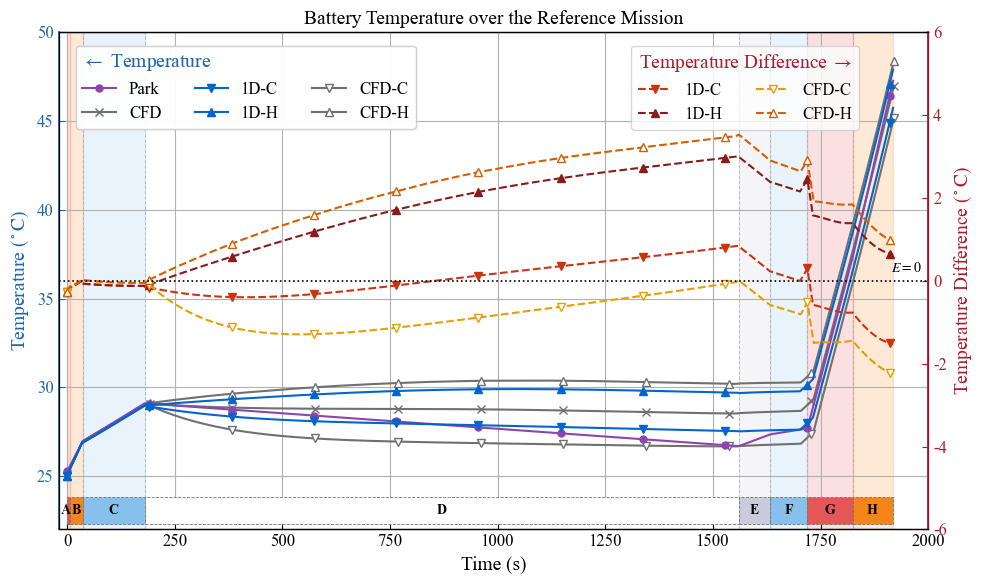

In [46]:
# plot the battery temperature over time
import matplotlib.pyplot as plt
from pyparsing import line
from matplotlib.patches import Rectangle
from matplotlib.transforms import blended_transform_factory

font_size = 12  # set the font size for the plot

# Apply the same scientific plotting style as the air-cooling figures.
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': font_size,
    'axes.labelsize': font_size,
    'axes.titlesize': font_size,
    'axes.titlesize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})


plt.figure(figsize=(10, 6))
# plt.plot(T_bat, label='T_bat (wo. cooling)(°C)')
# plot the battery temperature under air cooling as a dashed line
# plt.plot(T_bat_0D, label='T_bat,0D (°C)', linestyle='-.')

# plot the air outlet temperature profile for analysis
# plt.plot(T_air_out_0D, label='T_air,out, 0D (°C)', linestyle=':') # convert to Celsius for plotting


stages_bgcolors = ['#E45756','#F58518', "#87c1eb", "#FFFFFF", "#CBCBDD", '#87c1eb', '#E45756', '#F58518']  # background colors for each stage in the flight profile


# get the primary y-axis for plotting the battery temperature and air outlet temperature
ax1 = plt.gca()  # get the current axes for plotting the battery temperature and air outlet temperature

ax1.set_xlim(-20, 2000)  # set the x-axis limits based on the number of time steps
ax1.set_ylim(22, 50)
alpha_band = 0.18
# get the colormap 'Pastel1' of Matplotlib to use for the background colors of each stage in the flight profile
cmap = plt.get_cmap('Set3')
# plot the band for each stage with the specified background color
for i in range(len(t_park)):
    if i == 0:
        ax1.axvspan(0, t_park[i], color=stages_bgcolors[i], alpha=alpha_band, zorder=0)  # background color for each stage
    else:
        ax1.axvspan(t_park[i-1], t_park[i], color=stages_bgcolors[i], alpha=alpha_band, zorder=0)  # background color for each stage
    # plt.axvspan(t_park[i], t_park[i+1], color=cmap(i % cmap.N), alpha=0.4)  # background color for each stage

# Optional vertical boundaries
for boundary in t_park[1:-1]:
    ax1.axvline(
        boundary,
        color="0.65",
        linewidth=0.7,
        linestyle="--",
        alpha=0.7,
        zorder=1
    )

# x coordinate: data coordinates
# y coordinate: axes coordinates
trans = blended_transform_factory(ax1.transData, ax1.transAxes)

bar_bottom = 0.01
bar_height = 0.055

for i, name in enumerate(stages):
    t_start = 0 if i == 0 else t_park[i - 1]
    t_end = t_park[i]
    t_mid = (t_start + t_end) / 2
    duration = t_end - t_start

    offset = 5 if i == 0 else 0.0
    
    # Colored rectangle
    rect = Rectangle(
        (t_start, bar_bottom),
        duration,
        bar_height,
        transform=trans,
        facecolor=stages_bgcolors[i],
        edgecolor="0.45",
        linewidth=0.6,
        linestyle="--",
        clip_on=False,
        zorder=10,
        alpha=1.0
    )
    ax1.add_patch(rect)

    label = name.split(":")[0]  # Use the first part of the stage name for labeling
    
    # Full names can be shown horizontally in wide stages.
    # Use only S1, S2, ... in narrow stages.
    if duration >= 180:
        rotation = 0
        fontsize = font_size-2
    else:
        # label = name.split(":")[0]  # use only the first letter of the stage name for narrow stages
        rotation = 0
        fontsize = font_size-2

    ax1.text(
        t_mid-offset,
        bar_bottom + bar_height / 2,
        label,
        transform=trans,
        ha="center",
        va="center",
        rotation=rotation,
        fontsize=fontsize,
        fontweight='bold',
        color="black",
        clip_on=False,
        zorder=11
    )

mark_number = 10
mark_spacing = len(flow_time_cfd) // mark_number  # calculate the spacing for markers based on the number of data points and desired number of markers

# Left y-axis: temperature
left_style = {
    "Park":    dict(label='Park', color="#8E44AD", ls="-", marker="o"),
    "CFD_AVG": dict(label='CFD', color="#707070", ls="-", marker="x"),
    "CFD_MIN": dict(label='CFD-C', color="#707070", ls="-", marker="v",
                    markerfacecolor="white"),
    "CFD_MAX": dict(label='CFD-H', color="#707070", ls="-", marker="^",
                    markerfacecolor="white"),
    "1D_MIN":  dict(label='1D-C', color="#0066CC", ls="-", marker="v"),
    "1D_MAX":  dict(label='1D-H', color="#0066CC", ls="-", marker="^"),
}

# Right y-axis: temperature error
right_style = {
    "CFD_MIN": dict(label='CFD-C', color="#E69F00", ls="--", marker="v",
                    markerfacecolor="white"),
    "CFD_MAX": dict(label='CFD-H', color="#D55E00", ls="--", marker="^",
                    markerfacecolor="white"),
    "1D_MIN":  dict(label='1D-C', color="#CC3311", ls="--", marker="v"),
    "1D_MAX":  dict(label='1D-H', color="#8B1A1A", ls="--", marker="^"),
}

left_color = "#2166AC"
right_color = "#B2182B"


# plot the CFD temperature data for comparison
for t, (flow_time_cfd, report_def_0_cfd) in temperature_cfd_data.items():    
    
    line_style= left_style[f'CFD_{t.upper()}']  # get the line style for the current CFD type (avg, min, max)
    
    ax1.plot(
        flow_time_cfd,
        report_def_0_cfd - 273.15, 
        markevery=mark_spacing, 
        **line_style) # convert CFD temperature from K to °C for plotting


# ax1.plot(t_park, np.array(T_park) - 273.15, label=r'$T_\mathrm{b, Park}$ AVG', marker='o', linestyle='-.') # convert Park's temperature from K to °C for plotting
mark_spacing = len(t_smooth) // mark_number  # calculate the spacing for markers based on the number of data points and desired number of markers
line_style = left_style['Park']  # get the line style for Park's experimental data

ax1.plot(
    t_smooth, 
    T_park_smooth, 
    markersize=5, 
    markevery=mark_spacing,
    **line_style) # plot the smooth interpolated curve for Park's experimental data


line_style = left_style[f'1D_MIN']

ax1.plot(
    t_smooth, 
    T_bat_1D_min, 
    **line_style,
    markevery=mark_spacing) # plot the minimum battery temperature across segments as a dotted line

line_style = left_style[f'1D_MAX']
ax1.plot(
    t_smooth, 
    T_bat_1D_max, 
    **line_style,
    markevery=mark_spacing) # plot the maximum battery temperature across segments as a dotted line

# secondary axis for plotting the temperature difference between the 1D simulation and Park's experimental data

# plot the temperature difference between the 1D simulation and Park's experimental data on the twin y-axis

ax2 = ax1.twinx()  # create a twin y-axis for plotting the temperature difference between the 1D simulation and Park's experimental data

# set the limits for the twin y-axis based on the range of temperature differences
ax2.set_ylim(-6, 6)  # set the limits for the twin y-axis based on the range of temperature differences


marker_spacing = len(t_smooth) // mark_number  # calculate the spacing for markers based on the number of data points and desired number of markers

line_style = right_style['1D_MIN']
ax2.plot(
    t_smooth, 
    dTbat_1d_min_park,     
    **line_style,
    markevery=marker_spacing)  # plot the temperature difference for the minimum battery temperature

line_style = right_style['1D_MAX']
ax2.plot(
    t_smooth, 
    dTbat_1d_max_park, 
    **line_style, 
    markevery=marker_spacing)  # plot the temperature difference for the maximum battery temperature

line_style = right_style['CFD_MIN']
ax2.plot(
    t_smooth, 
    dTbat_cfd_min_park,
    **line_style,
    markevery=marker_spacing,)  # plot the temperature difference for the minimum CFD battery temperature

line_style = right_style['CFD_MAX']
ax2.plot(
    t_smooth, 
    dTbat_cfd_max_park, 
    **line_style,
    markevery=marker_spacing,)  # plot the temperature difference for the maximum CFD battery temperature

ax2.axhline(0, color='black', linestyle=':', linewidth=1.2)  # plot a horizontal line at y=0 for reference  
ax2.annotate(
    r"$E=0$",
    xy=(1.0, 0),
    xycoords=("axes fraction", "data"),
    xytext=(-5, 4),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=font_size-2,
    color="0"
)

ax1.set_xlabel('Time (s)', fontsize=font_size+2)
ax1.set_ylabel(r"Temperature ($^\circ\mathrm{C}$)", color=left_color, fontsize=font_size+2)
ax1.tick_params(axis="y", colors=left_color)
ax1.spines["left"].set_color(left_color)
ax1.spines["left"].set_linewidth(1.3)

ax2.set_ylabel(r"Temperature Difference ($^\circ\mathrm{C}$)", color=right_color, fontsize=font_size+2)
ax2.tick_params(axis="y", colors=right_color)
ax2.spines["right"].set_color(right_color)
ax2.spines["right"].set_linewidth(1.3)

ax1.set_title('Battery Temperature over the Reference Mission', fontsize=font_size+2)

handles_left, labels_left = ax1.get_legend_handles_labels()  # get the handles and labels for the primary y-axis legend

handle_order = [3, 0, 4, 5, 2, 1]  # specify the order of the legend entries for the primary y-axis legend
handles_left = [handles_left[i] for i in handle_order]
labels_left = [labels_left[i] for i in handle_order]

handles_right, labels_right = ax2.get_legend_handles_labels()  # get the handles and labels for the secondary y-axis legend

leg1 = ax1.legend(
    handles_left,
    labels_left,
    # title="Temperature - left axis",    
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    ncol=3,
    # labelcolor=left_color,
    fontsize=font_size,
    alignment='left'
)
leg1.set_title(r"$\leftarrow$ Temperature", prop={"size": font_size+2})
leg1.get_title().set_color(left_color)


leg2 = ax2.legend(
    handles_right,
    labels_right,
    # title="Temperature Difference - right axis",
    # labelcolor=right_color,
    loc="upper right",
    bbox_to_anchor=(0.93, 0.99),
    ncol=2,
    fontsize=font_size,
    alignment='right'
)
leg2.set_title(r"Temperature Difference $\rightarrow$", prop={"size": font_size+2})
leg2.get_title().set_color(right_color)

ax1.add_artist(leg1)

ax1.grid()

plt.tight_layout()

# save the plot as a vector graphic (SVG) and a high-resolution PNG for publication purposes
plot_file_name = os.path.join(PROJECT_ROOT, 'out', CASE_ID, f'{CASE_NAME}.pdf')

if(not os.path.exists(os.path.dirname(plot_file_name))):
    os.makedirs(os.path.dirname(plot_file_name))

plt.savefig(
    plot_file_name,
    dpi=600,
    bbox_inches='tight'
)

# also save one to the paper's working directory

paper_wd = r"D:\Workspace\Paper_eBATS\images"

plt.savefig(
    os.path.join(paper_wd, f'{CASE_NAME}.pdf'),
    dpi=600,
    bbox_inches='tight'
)


plt.show()

(array([  6., 132.,  70.,  25.,  27.,  29.,  27.,  30.,  30.,  41.,  53.,
         48.,  49.,  49.,  49.,  48., 111.,  72.,  48.,  50.,  51.,  56.,
         61., 108., 117.,  99., 110., 113., 118.,  92.]),
 array([-0.27      , -0.14326532, -0.01653064,  0.11020404,  0.23693872,
         0.3636734 ,  0.49040808,  0.61714276,  0.74387743,  0.87061211,
         0.99734679,  1.12408147,  1.25081615,  1.37755083,  1.50428551,
         1.63102019,  1.75775487,  1.88448955,  2.01122423,  2.13795891,
         2.26469359,  2.39142827,  2.51816295,  2.64489763,  2.7716323 ,
         2.89836698,  3.02510166,  3.15183634,  3.27857102,  3.4053057 ,
         3.53204038]),
 <BarContainer object of 30 artists>)

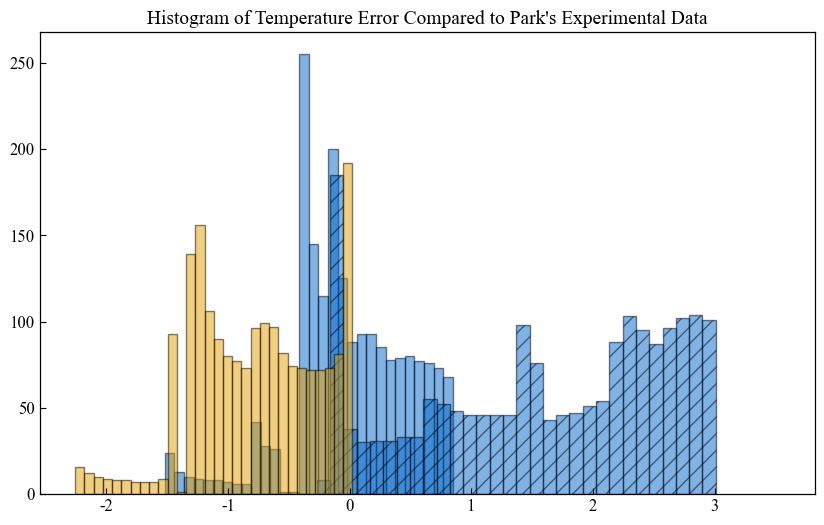

In [21]:
# Draw a histogram of the temperature error for the 1D simulation and CFD results compared to Park's experimental data.

import matplotlib.pyplot as plt


comparison_data = {
    '1D_MIN': (comparison_1d_min_park, dTbat_1d_min_park),
    '1D_MAX': (comparison_1d_max_park, dTbat_1d_max_park),
    'CFD_MIN': (comparison_cfd_min_park, dTbat_cfd_min_park),
    'CFD_MAX': (comparison_cfd_max_park, dTbat_cfd_max_park)
}

# Draw a histogram of the temperature error for the 1D simulation and CFD results compared to Park's experimental data.

plt.figure(figsize=(10, 6))

ax1 = plt.gca()  # get the current axes for plotting the histogram
ax1.set_title('Histogram of Temperature Error Compared to Park\'s Experimental Data', fontsize=font_size+2)


ax1.hist(
    comparison_1d_min_park[], bins=30, alpha=0.5, label='1D MIN', color="#0066CC", edgecolor='black')
ax1.hist(
    dTbat_1d_max_park, bins=30, alpha=0.5, label='1D MAX', color="#0066CC", edgecolor='black', hatch='//')
ax1.hist(
    dTbat_cfd_min_park, bins=30, alpha=0.5, label='CFD MIN', color="#E69F00", edgecolor='black')
ax1.hist(
    dTbat_cfd_max_park, bins=30, alpha=0, label='CFD MAX', color="#D55E00", edgecolor='black', hatch='//')




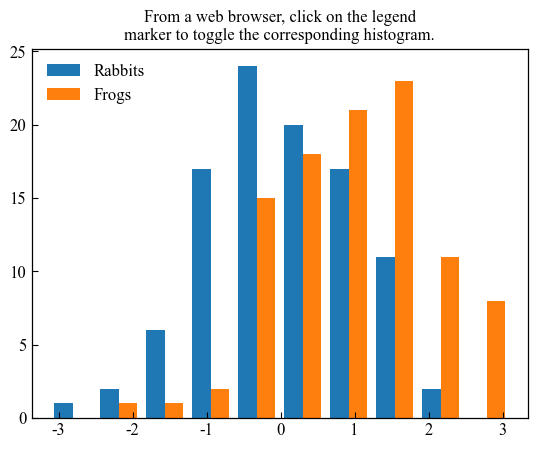

In [22]:
from io import BytesIO
import json
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['svg.fonttype'] = 'none'

# Apparently, this `register_namespace` method is necessary to avoid garbling
# the XML namespace with ns0.
ET.register_namespace("", "http://www.w3.org/2000/svg")

# Fixing random state for reproducibility
np.random.seed(19680801)

# --- Create histogram, legend and title ---
plt.figure()
r = np.random.randn(100)
r1 = r + 1
labels = ['Rabbits', 'Frogs']
H = plt.hist([r, r1], label=labels)
containers = H[-1]
leg = plt.legend(frameon=False)
plt.title("From a web browser, click on the legend\n"
          "marker to toggle the corresponding histogram.")


# --- Add ids to the svg objects we'll modify

hist_patches = {}
for ic, c in enumerate(containers):
    hist_patches[f'hist_{ic}'] = []
    for il, element in enumerate(c):
        element.set_gid(f'hist_{ic}_patch_{il}')
        hist_patches[f'hist_{ic}'].append(f'hist_{ic}_patch_{il}')

# Set ids for the legend patches
for i, t in enumerate(leg.get_patches()):
    t.set_gid(f'leg_patch_{i}')

# Set ids for the text patches
for i, t in enumerate(leg.get_texts()):
    t.set_gid(f'leg_text_{i}')

# Save SVG in a fake file object.
f = BytesIO()
plt.savefig(f, format="svg")

# Create XML tree from the SVG file.
tree, xmlid = ET.XMLID(f.getvalue())


# --- Add interactivity ---

# Add attributes to the patch objects.
for i, t in enumerate(leg.get_patches()):
    el = xmlid[f'leg_patch_{i}']
    el.set('cursor', 'pointer')
    el.set('onclick', "toggle_hist(this)")

# Add attributes to the text objects.
for i, t in enumerate(leg.get_texts()):
    el = xmlid[f'leg_text_{i}']
    el.set('cursor', 'pointer')
    el.set('onclick', "toggle_hist(this)")

# Create script defining the function `toggle_hist`.
# We create a global variable `container` that stores the patches id
# belonging to each histogram. Then a function "toggle_element" sets the
# visibility attribute of all patches of each histogram and the opacity
# of the marker itself.

script = """
<script type="text/ecmascript">
<![CDATA[
var container = %s

function toggle(oid, attribute, values) {
    /* Toggle the style attribute of an object between two values.

    Parameters
    ----------
    oid : str
      Object identifier.
    attribute : str
      Name of style attribute.
    values : [on state, off state]
      The two values that are switched between.
    */
    var obj = document.getElementById(oid);
    var a = obj.style[attribute];

    a = (a == values[0] || a == "") ? values[1] : values[0];
    obj.style[attribute] = a;
    }

function toggle_hist(obj) {

    var num = obj.id.slice(-1);

    toggle('leg_patch_' + num, 'opacity', [1, 0.3]);
    toggle('leg_text_' + num, 'opacity', [1, 0.5]);

    var names = container['hist_'+num]

    for (var i=0; i < names.length; i++) {
        toggle(names[i], 'opacity', [1, 0])
    };
    }
]]>
</script>
""" % json.dumps(hist_patches)

# Add a transition effect
css = tree.find('.//{http://www.w3.org/2000/svg}style')
css.text = css.text + "g {-webkit-transition:opacity 0.4s ease-out;" + \
    "-moz-transition:opacity 0.4s ease-out;}"

# Insert the script and save to file.
tree.insert(0, ET.XML(script))

ET.ElementTree(tree).write("svg_histogram.svg")